In [1]:
import os
import ot
import gc
import k3d
import torch
import trimesh
import warnings
from tqdm import *
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
import scipy.sparse as sp
import matplotlib.cm as cm
from anndata import AnnData
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from numpy.random import RandomState
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
from sklearn.metrics import jaccard_score
from scipy.stats import fisher_exact, norm
from sklearn.neighbors import NearestNeighbors
from typing import Literal, Optional, Tuple, Union
from matplotlib.colors import ListedColormap, rgb2hex
from sklearn.metrics.pairwise import euclidean_distances
from matplotlib.font_manager import fontManager, FontProperties
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import marsilea as ma
import re

In [2]:
adata_path = "/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/rapids_analysis/merfish_mouseBrain_concat_embeddings.h5ad"
csv_path = "/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/example/05_merfish_mouseBrain/cluster_to_cluster_annotation_membership.csv"
json_path = "/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/rapids_analysis/author_colormaps/author_colormap.json"


adata = sc.read_h5ad(adata_path)
df = pd.read_csv(csv_path)

def strip_author_id(x):
    return re.sub(r"^\s*\d+\s+", "", str(x)).strip()

class_df = df[df["cluster_annotation_term_set_name"] == "class"].copy()
class_df["cluster_alias"] = class_df["cluster_alias"].astype(str)
class_df["author_class"] = class_df["cluster_annotation_term_name"].map(strip_author_id)

cluster_to_class = (
    class_df
    .drop_duplicates("cluster_alias")
    .set_index("cluster_alias")["author_class"]
    .to_dict()
)

adata.obs["author_class"] = (
    adata.obs["cluster_id_transfer"]
    .astype(str)
    .map(cluster_to_class)
    .astype("category")
)

In [3]:
import json

with open(json_path, "r", encoding="utf-8") as f:
    author_cmap = json.load(f)

print(author_cmap.keys())

dict_keys(['source_membership', 'source_h5ad', 'obs_key_palettes', 'author_term_set_palettes'])


In [4]:
author_cmap['author_term_set_palettes'].keys()

dict_keys(['cluster', 'supertype', 'subclass', 'class', 'neurotransmitter'])

In [5]:
class_palette = author_cmap["author_term_set_palettes"]["class"]
cluster_palette = author_cmap["obs_key_palettes"]["cluster_id_transfer"]
# subclass_palette = author_cmap["obs_key_palettes"]["subclass_transfer"]
subclass_palette = author_cmap['author_term_set_palettes']['subclass']

In [6]:
cell_leiden_colormap = {
    '11': '#a9889b', '28': '#55f0e9',
 '10': '#03683d', '44': '#68d346', '20': '#063f88', '46': '#aef741', '39': '#e23cd3', '6': '#ddd34f', '53': '#f3e716', '35': '#96b751',
 '30': '#5eed8b', '25': '#13bf07', '42': '#70bed8', '8': '#014d3c', '19': '#169739', '16': '#364fc9', '32': '#49bf04', '18': '#da404e',
 '27': '#3ee944', '52': '#3c2b33', '12': '#329e27', '36': '#4a7e21', '2': '#b8dcb8', '29': '#3ff72d', '9': '#ae3e99', '47': '#1af166',
 '43': '#d6a07b', '50': '#685c07', '48': '#e6e289', '51': '#419ea8', '40': '#1ce209', '22': '#2b968c', '31': '#2b3a18', '49': '#888561',
 '7': '#ce3af9', '4': '#84a490', '23': '#1ed53a', '41': '#d5a20a', '17': '#036f90', '34': '#f97905', '33': '#de0045', '13': '#0f2cec', 
    '38': '#1c2092', '26': '#6b1bfc', '3': '#907d9f',
 '37': '#966844', '45': '#b22f78', '14': '#a0979d', '24': '#10fb09', '5': '#013689', '0': '#19a7b9', '21': '#bea139', '15': '#fd3cdf',
    '1': '#fefa2d'}
major_brain_region_colormap = {
    'Midbrain': '#FFA6FF', 'Cerebellum': '#FFFDBC',
 'Isocortex': '#0D9F91', 'Hippocampus': '#62178d', 'Cortical_subplate': '#97EC93',
 'Medulla': '#FFA6FF', 'Olfactory': '#A8ECD3', 'Fiber_tracts': '#CBCBCB',
 'Thalamus': '#FF909F', 'Hypothalamus': '#F2483B', 'Pallidum': '#B3C0DF',
 'Pons': '#FFA6FF', 'Striatum': '#80C0E2', 'Ventricular_systems': '#AAAAAA', 'n/a': '#8fec63'
}
niche_leiden_colormap = {
    '4': '#24ea8d', '5': '#981cb1',
 '3': '#fc821e', '26': '#518e40', '15': '#47c87b', '17': '#217262', '36': '#9b43a3', '21': '#9d0201', '13': '#33420e', '22': '#93b2a3',
 '23': '#f90830', '25': '#cd94e2', '41': '#5409fe', '0': '#07d774', '42': '#3cdf1a', '48': '#9b50f2', '18': '#b18e8a', '40': '#391dbf',
 '32': '#a97778', '35': '#bb75bb', '6': '#3964ff', '46': '#cce234', '29': '#c73148', '28': '#90fb22', '14': '#022a83', '37': '#649b41',
 '10': '#42b3cc', '19': '#25d0a1', '2': '#bea66e', '38': '#24a568', '45': '#fb08f0', '24': '#598890', '20': '#3f8ee2', '33': '#da6918',
 '43': '#dffbec', '27': '#6e70d2', '11': '#c01c96', '49': '#ea5dd7', '44': '#519017', '1': '#5e319e', '12': '#7de88c', '16': '#3ef055',
 '47': '#2cf922', '30': '#c9af2a', '9': '#803891', '34': '#bf2654', '39': '#83b355', '7': '#1a9bbd', '31': '#06c0bb', '8': '#085d87',
}

In [7]:
donor_id_colormap = {
    'C57BL6J-1': '#73BBF4', 
    'C57BL6J-2': '#284D76', 
    'C57BL6J-3': '#DF95D5', 
    'C57BL6J-4': '#791E25',
}

In [10]:
import matplotlib.pyplot as plt

def add_umap_axis_arrow(
    ax,
    label_x="UMAP 1",
    label_y="UMAP 2",
    x_start=0.08,
    y_start=0.08,
    length=0.16,
    color="black",
    lw=1.2,
    fontsize=8,
    label_pad=0.015,
):
    ax.annotate(
        "",
        xy=(x_start + length, y_start),
        xytext=(x_start, y_start),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            shrinkA=0,
            shrinkB=0,
            mutation_scale=10,
        ),
    )

    ax.annotate(
        "",
        xy=(x_start, y_start + length),
        xytext=(x_start, y_start),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            shrinkA=0,
            shrinkB=0,
            mutation_scale=10,
        ),
    )

    ax.text(
        x_start + length / 2,
        y_start - label_pad,
        label_x,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=fontsize,
        color=color,
    )

    ax.text(
        x_start - label_pad,
        y_start + length / 2,
        label_y,
        transform=ax.transAxes,
        ha="right",
        va="center",
        rotation=90,
        fontsize=fontsize,
        color=color,
    )

In [12]:
plot = sc.pl.embedding(
        adata, basis="X_umap_cell", color='donor_id',
        show=False, s=0.03, palette = donor_id_colormap, frameon = False, title = '',legend_loc  = None
    )
plot.set_aspect('equal')
add_umap_axis_arrow(
    plot,
    label_x="Cell UMAP1",
    label_y="Cell UMAP2",
    x_start=0.08,
    y_start=0.08,
    length=0.15,
    color="black",
    lw=1.2,
    fontsize=8,
    label_pad=0.006,
)

plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/cell_uamp_donor_id.png", 
            bbox_inches="tight",
            transparent=True,
            facecolor='none',
            dpi = 450)
plt.close()

In [13]:


plot = sc.pl.embedding(
        adata, basis="X_umap_niche", color='donor_id',
        show=False, s=0.03, palette = donor_id_colormap, frameon = False, title = '',legend_loc  = None
    )
plot.set_aspect('equal')
add_umap_axis_arrow(
    plot,
    label_x="Niche UMAP1",
    label_y="Niche UMAP2",
    x_start=0.08,
    y_start=0.08,
    length=0.15,
    color="black",
    lw=1.2,
    fontsize=8,
    label_pad=0.006,
)
plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/niche_uamp_donor_id.png", 
            bbox_inches="tight",
            transparent=True,
            facecolor='none',
            dpi = 450)
plt.close()

In [14]:
cell_leiden_dic = {
    'ob cell': ['41','28', '16', '20', '25', '26', '48', '36'], # ob cell
    'ctx cell': ['22', '17', '10', '23', '27', '33', '29', '37', '45', '38', '39', '24', '40',], # ctx cell
    'cnu cell': ['18', '32', '46', '50', '0', ], # cnu cell
    'cb cell': ['21', '14', '44'],
}
for celltype in cell_leiden_dic:
    plot = sc.pl.embedding(
            adata, basis="X_umap_cell", color='cell_leiden',
            show=False, s=0.03, palette = cell_leiden_colormap, frameon = False, title = '', groups = cell_leiden_dic[celltype],
        legend_loc  = None
        )
    plot.set_aspect('equal')
    add_umap_axis_arrow(
        plot,
        label_x="Cell UMAP1",
        label_y="Cell UMAP2",
        x_start=0.08,
        y_start=0.08,
        length=0.15,
        color="black",
        lw=1.2,
        fontsize=8,
        label_pad=0.006,
    )
    plt.savefig(f"/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/cell_uamp_cell_leiden_{celltype}.png", 
                bbox_inches="tight",
                transparent=True,
                facecolor='none',
                dpi = 450)
    plt.close()

In [15]:
author_class_dic = {
    'ob cell': ['OB-CR Glut','OB-IMN GABA','OEC'], # ob cell
    'ctx cell': ['CTX-CGE GABA','CTX-MGE GABA','IT-ET Glut', 'NP-CT-L6b Glut'], # ctx cell
    'cnu cell': ['CNU-LGE GABA','CNU-MGE GABA','LSX GABA','CNU-HYa GABA','CNU-HYa Glut',], # cnu cell
    'cb cell': ['CB GABA','CB Glut',], # cb cell
}
for celltype in author_class_dic:
    plot = sc.pl.embedding(
            adata, basis="X_umap_cell", color='author_class',
            show=False, s=0.03, palette = class_palette, frameon = False, title = '', groups = author_class_dic[celltype],
        legend_loc  = None
        )
    plot.set_aspect('equal')
    add_umap_axis_arrow(
        plot,
        label_x="Cell UMAP1",
        label_y="Cell UMAP2",
        x_start=0.08,
        y_start=0.08,
        length=0.15,
        color="black",
        lw=1.2,
        fontsize=8,
        label_pad=0.006,
    )
    plt.savefig(f"/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/cell_uamp_author_class_{celltype}.png", 
                bbox_inches="tight",
                transparent=True,
                facecolor='none',
                dpi = 450)
    plt.close()

In [18]:
niche_leiden_dic = {
    'ob region': ['17', '10', '14', '41', '33', '23', '36'], # ob cell
    'isoCortex region': ['20', '28', '32', '45'], # ctx cell
    'hip region': ['24','31','34', '26', '27', '0'], # cnu cell
    # 'cb cell': ['CB GABA','CB Glut',], # cb cell
}
for niche in niche_leiden_dic:
    plot = sc.pl.embedding(
            adata, basis="X_umap_niche", color='niche_leiden',
            show=False, s=0.03, palette = niche_leiden_colormap, frameon = False, title = '', groups = niche_leiden_dic[niche],
        legend_loc  = None
        )
    plot.set_aspect('equal')
    add_umap_axis_arrow(
        plot,
        label_x="Niche UMAP1",
        label_y="Niche UMAP2",
        x_start=0.08,
        y_start=0.08,
        length=0.15,
        color="black",
        lw=1.2,
        fontsize=8,
        label_pad=0.006,
    )
    plt.savefig(f"/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/cell_uamp_niche_leiden_{niche}.png", 
                bbox_inches="tight",
                transparent=True,
                facecolor='none',
                dpi = 450)
    plt.close()

In [19]:
plot = sc.pl.embedding(
        adata, basis="X_umap_cell", color='author_class',
        show=False, s=0.03, palette = class_palette, frameon = False, title = '',
    legend_loc  = None
    )
plot.set_aspect('equal')
add_umap_axis_arrow(
    plot,
    label_x="Cell UMAP1",
    label_y="Cell UMAP2",
    x_start=0.08,
    y_start=0.08,
    length=0.15,
    color="black",
    lw=1.2,
    fontsize=8,
    label_pad=0.006,
)
plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/cell_uamp_author_class.png", 
            bbox_inches="tight",
            transparent=True,
            facecolor='none',
            dpi = 450)
plt.close()
# plt.show()

plot = sc.pl.embedding(
        adata, basis="X_umap_niche", color='major_brain_region',
        show=False, s=0.03, palette = major_brain_region_colormap, frameon = False, title = '',
    legend_loc  = None
    )
plot.set_aspect('equal')
add_umap_axis_arrow(
    plot,
    label_x="Niche UMAP1",
    label_y="Niche UMAP2",
    x_start=0.08,
    y_start=0.08,
    length=0.15,
    color="black",
    lw=1.2,
    fontsize=8,
    label_pad=0.006,
)
plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/niche_uamp_major_brain_region.png", 
            bbox_inches="tight",
            transparent=True,
            facecolor='none',
            dpi = 450)
plt.close()
# plt.show()


plot = sc.pl.embedding(
        adata, basis="X_umap_cell", color='cell_leiden',
        show=False, s=0.03, palette = cell_leiden_colormap, frameon = False, title = '',
    legend_loc  = None
    )
plot.set_aspect('equal')
add_umap_axis_arrow(
    plot,
    label_x="Cell UMAP1",
    label_y="Cell UMAP2",
    x_start=0.08,
    y_start=0.08,
    length=0.15,
    color="black",
    lw=1.2,
    fontsize=8,
    label_pad=0.006,
)
plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/cell_uamp_cell_leiden.png", 
            bbox_inches="tight",
            transparent=True,
            facecolor='none',
            dpi = 450)
plt.close()
# plt.show()

plot = sc.pl.embedding(
        adata, basis="X_umap_niche", color='niche_leiden',
        show=False, s=0.03, palette = niche_leiden_colormap, frameon = False, title = '',
    legend_loc  = None
    )
plot.set_aspect('equal')
add_umap_axis_arrow(
    plot,
    label_x="Niche UMAP1",
    label_y="Cell UMAP2",
    x_start=0.08,
    y_start=0.08,
    length=0.15,
    color="black",
    lw=1.2,
    fontsize=8,
    label_pad=0.006,
)
plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/niche_uamp_niche_leiden.png", 
            bbox_inches="tight",
            transparent=True,
            facecolor='none',
            dpi = 450)
plt.close()
# plt.show()

In [38]:
for celltype in set(adata.obs['author_class']):
    plot = sc.pl.embedding(
            adata, basis="X_umap_cell", color='author_class',
            show=False, s=0.03, palette = class_palette, frameon = False, title = '', groups = [celltype],
        legend_loc  = None
        )
    plot.set_aspect('equal')
    plt.savefig(f"/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/cell_uamp_author_class_{celltype}.png", 
                bbox_inches="tight",
                transparent=True,
                facecolor='none',
                dpi = 450)
    plt.close()

In [ ]:
for niche in set(adata.obs['major_brain_region']):
    if not niche:
        continue
    if '/' in niche:
        continue
    if os.path.exists(f"/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/niche_uamp_major_brain_region_{niche}.png"):
        continue
    plot = sc.pl.embedding(
            adata, basis="X_umap_niche", color='major_brain_region',
            show=False, s=0.03, palette = major_brain_region_colormap, frameon = False, title = '', groups = [niche],
        legend_loc  = None
        )
    plot.set_aspect('equal')
    
    plt.savefig(f"/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/niche_uamp_major_brain_region_{niche}.png", 
                bbox_inches="tight",
                transparent=True,
                facecolor='none',
                dpi = 450)
    plt.close()

In [37]:
import os
import numpy as np
import scanpy as sc
import k3d


def obs_3d_plot(
    adata_input,
    obs_key,
    spatial_key,
    colormap,
    output_html=None,
    groups=None,
    camera=None,
    point_size=80.0,
    opacity=0.85,
    scale=1.0,
    background_color=0xffffff,
    max_points_per_group=None,
    seed=0,
):
    """
    在 3D 空间中按照 adata.obs[obs_key] 绘制细胞类型 / 标签。

    Parameters
    ----------
    adata_input:
        AnnData 对象，或 h5ad 路径。
    obs_key:
        adata.obs 中的标签列，比如 "author_class", "cell_type", "subclass_transfer"。
    spatial_key:
        adata.obsm 中的 3D 坐标 key，比如 "ccf", "X_CCF", "X_spatial_coords"。
    colormap:
        dict，格式为 {"label": "#RRGGBB"}。
    output_html:
        如果提供路径，则保存 k3d html。
    groups:
        只绘制指定标签，比如 ["IT-ET Glut", "GABA"]。默认绘制全部。
    camera:
        k3d camera 参数。
    max_points_per_group:
        每个类别最多画多少点，用于大数据降采样。
    """

    if isinstance(adata_input, str):
        adata = sc.read_h5ad(adata_input)
    else:
        adata = adata_input

    if obs_key not in adata.obs:
        raise ValueError(f"adata.obs 中找不到 {obs_key}")

    if spatial_key not in adata.obsm:
        raise ValueError(f"adata.obsm 中找不到 {spatial_key}")

    coords = np.asarray(adata.obsm[spatial_key])
    if coords.shape[1] < 3:
        raise ValueError(f"adata.obsm['{spatial_key}'] 只有 {coords.shape[1]} 维，不能画 3D")

    positions = (coords[:, :3] * scale).astype(np.float32) * 9.8

    labels = adata.obs[obs_key].astype(str).to_numpy()

    if groups is None:
        if hasattr(adata.obs[obs_key], "cat"):
            categories = list(adata.obs[obs_key].cat.categories.astype(str))
        else:
            categories = sorted(pd.unique(labels))
    else:
        categories = [str(x) for x in groups]

    rng = np.random.default_rng(seed)

    plot = k3d.plot(
        name=f"3D {obs_key}",
        background_color=background_color,
        camera_auto_fit=False,
    )

    mesh = trimesh.load('/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/example/03_Han_Neuron/average_template_10_sur.stl')
    
    plot = k3d.plot(name="Gene Expression 3D Plot",background_color=0xffffff,camera_auto_fit=False)
    
    stl_mesh = k3d.mesh(
        vertices=mesh.vertices.astype(np.float32),
        indices  =mesh.faces.astype(np.uint32),
        color    =0xB0B0B0,
        opacity  =0.20,
        wireframe=False,
        name='mouseMesh'
    )
    plot += stl_mesh
    
    for cat in categories:
        mask = labels == cat
        idx = np.where(mask)[0]

        if len(idx) == 0:
            print(f"跳过 {cat}: 没有细胞")
            continue

        if cat not in colormap:
            print(f"警告: {cat} 不在 colormap 中，使用灰色")
            color_hex = "#B0B0B0"
        else:
            color_hex = colormap[cat]

        if max_points_per_group is not None and len(idx) > max_points_per_group:
            idx = rng.choice(idx, size=max_points_per_group, replace=False)

        color_int = int(color_hex.lstrip("#"), 16)

        point_cloud = k3d.points(
            positions[idx],
            color=color_int,
            point_size=point_size,
            opacity=opacity,
            shader="3d",
            name=f"{cat} ({len(idx)})",
        )

        plot += point_cloud

    if camera is not None:
        plot.camera = camera

    plot.grid_visible = False
    plot.camera = [
        11485.284267462972,
        -14993.204389281993,
        127606.14254467492,
        69173.64700316277,
        57841.691822745124,
        43527.33431330532,
        0.21578089746207177,
        -0.8402988312227976,
        -0.4973293461440416]
    if output_html is not None:
        os.makedirs(os.path.dirname(output_html), exist_ok=True)
        with open(output_html, "w", encoding="utf-8") as f:
            f.write(plot.get_snapshot())

    return plot

In [39]:
plot = obs_3d_plot(
    adata,
    obs_key="author_class",
    spatial_key="X_CCF",
    colormap=class_palette,
    output_html="/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/test_author_class_3d.html",
    point_size=50,
    opacity=1,
    scale=1.0,
)

/home/share/huadjyin/home/zhoutao3/.conda/envs/stereotrack_2/lib/python3.10/site-packages/traittypes/traittypes.py:98: UserWarning: Given trait value dtype "float32" does not match required type "float32". A coerced copy has been created.
  warnings.warn(
/home/share/huadjyin/home/zhoutao3/.conda/envs/stereotrack_2/lib/python3.10/site-packages/traittypes/traittypes.py:98: UserWarning: Given trait value dtype "uint32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


In [40]:
plot = obs_3d_plot(
    adata,
    obs_key="cell_leiden",
    spatial_key="X_CCF",
    colormap=cell_leiden_colormap,
    output_html="/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/test_cell_leiden_3d.html",
    point_size=50,
    opacity=1,
    scale=1.0,
)

/home/share/huadjyin/home/zhoutao3/.conda/envs/stereotrack_2/lib/python3.10/site-packages/traittypes/traittypes.py:98: UserWarning: Given trait value dtype "float32" does not match required type "float32". A coerced copy has been created.
  warnings.warn(
/home/share/huadjyin/home/zhoutao3/.conda/envs/stereotrack_2/lib/python3.10/site-packages/traittypes/traittypes.py:98: UserWarning: Given trait value dtype "uint32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


In [ ]:
plot = obs_3d_plot(
    adata,
    obs_key="major_brain_region",
    spatial_key="X_CCF",
    colormap=major_brain_region_colormap,
    output_html="/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/test_major_brain_region_3d.html",
    point_size=50,
    opacity=1,
    scale=1.0,
)

In [ ]:
plot = obs_3d_plot(
    adata,
    obs_key="niche_leiden",
    spatial_key="X_CCF",
    colormap=niche_leiden_colormap,
    output_html="/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/test_niche_leiden_3d.html",
    point_size=50,
    opacity=1,
    scale=1.0,
)

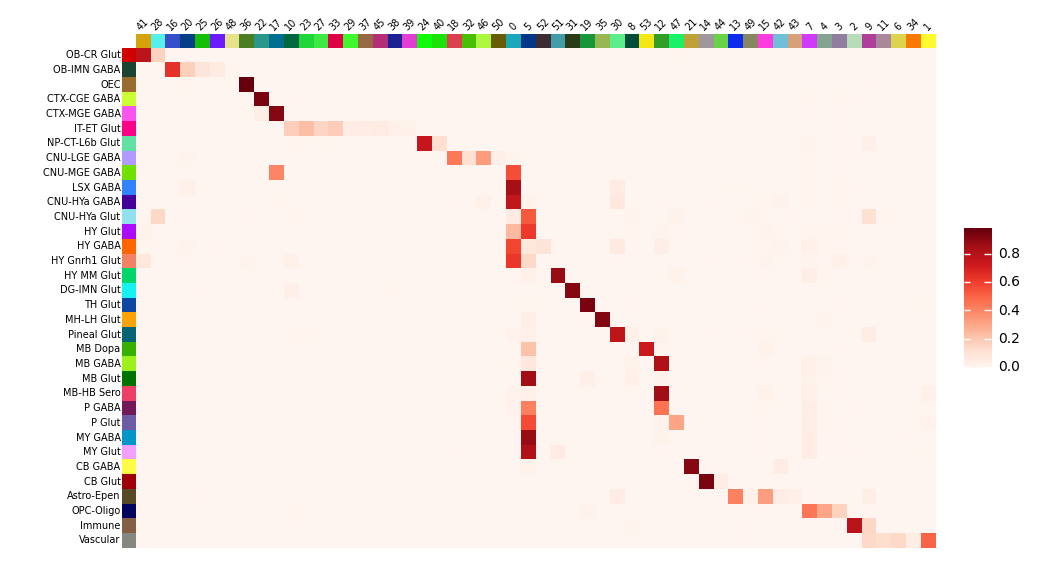

In [8]:
confusion_matrix = pd.crosstab(
    adata.obs['author_class'], 
    adata.obs['cell_leiden'], 
    normalize='index'
)

author_class_order = [
    'OB-CR Glut','OB-IMN GABA','OEC','CTX-CGE GABA','CTX-MGE GABA','IT-ET Glut',
    'NP-CT-L6b Glut','CNU-LGE GABA','CNU-MGE GABA','LSX GABA','CNU-HYa GABA','CNU-HYa Glut',
    'HY Glut','HY GABA','HY Gnrh1 Glut','HY MM Glut','DG-IMN Glut','TH Glut','MH-LH Glut',
    'Pineal Glut','MB Dopa','MB GABA','MB Glut','MB-HB Sero','P GABA',
    'P Glut','MY GABA','MY Glut','CB GABA','CB Glut',
    'Astro-Epen','OPC-Oligo','Immune','Vascular',
]

cell_leiden_order =[
    '41', '28', '16', '20', '25', '26', '48', 
    '36', '22', '17','10','23','27', '33','29','37','45', '38', '39',
    '24', '40', '18', '32', '46', '50', '0',  '5', '52', '51', '31', 
    '19', '35', '30', '8', '53', '12', '47',
    '21',  '14', '44',
    '13', '49', '15', '42', '43', '7', '4', '3', '2', '9', '11', '6', '34', '1', 
]

confusion_matrix = confusion_matrix.loc[author_class_order]
confusion_matrix = confusion_matrix[cell_leiden_order]

gene_profile = ma.Heatmap(
        confusion_matrix,
        height=5,
        width=8,
        cmap="Reds",
)

gene_profile.group_rows(author_class_order, order=author_class_order, spacing=0)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=[' ' for i in range(len(author_class_order))], 
        padding=0, 
        fill_colors=[class_palette[i] for i in author_class_order], 
        borderwidth=0
    ),
    pad=0.001
)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=author_class_order,
        padding=0.2,
        fill_colors=None,
        borderwidth=0,
        rotation=0,
        props={"fontsize": 7},
    ),
    pad=0.01
)

gene_profile.group_cols(cell_leiden_order, order=cell_leiden_order,spacing = 0)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts = [' ' for i in range(len(cell_leiden_order))], 
        padding=0, 
        fill_colors = [cell_leiden_colormap[i] for i in cell_leiden_order], 
        borderwidth = 0
    ),
    pad=0.001
)

gene_profile.add_top(
    ma.plotter.Chunk(
        texts=cell_leiden_order,
        padding=0.2,
        fill_colors=None, 
        borderwidth=0,
        rotation=45,
        props={"fontsize": 7},
    ),
    pad=0.01
)

gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()

plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/confusion_matrix_celltype.pdf", bbox_inches="tight",transparent=True,facecolor='none')
plt.show()

In [23]:
confusion_matrix = pd.crosstab(
    adata.obs['major_brain_region'], 
    adata.obs['niche_leiden'], 
    normalize='index'
)

In [31]:
confusion_matrix[['49']]

niche_leiden,49
major_brain_region,
Olfactory,0.000000
Isocortex,0.000000
Cortical_subplate,0.000000
Hippocampus,0.000000
Striatum,0.000000
Pallidum,0.000000
Hypothalamus,0.000000
Thalamus,0.000000
Midbrain,0.001335


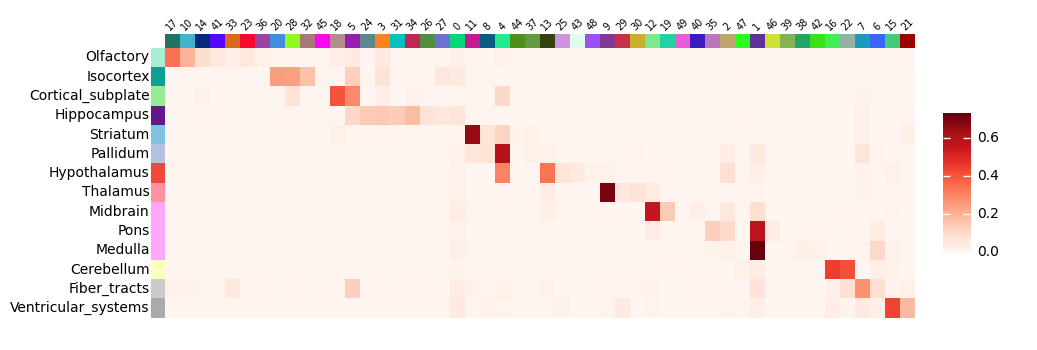

In [34]:




major_brain_region_order = [
    'Olfactory','Isocortex','Cortical_subplate','Hippocampus',
    'Striatum','Pallidum','Hypothalamus','Thalamus','Midbrain',
    'Pons','Medulla','Cerebellum',
    'Fiber_tracts','Ventricular_systems'
]

niche_leiden_order = [
    '17', '10', '14', '41', '33', '23', '36', '20', '28', '32', '45', '18', '5', 
    '24', '3', '31', '34', '26', '27',
    '0', '11', '8', '4', '44', '37', '13', '25', '43', '48', '9', '29', '30',
    '12',  '19',  '49','40', '35', '2', '47', '1', '46', '39', '38', '42',
    '16', '22',
    '7', '6', 
    '15', '21',  
 ]

confusion_matrix = confusion_matrix.loc[major_brain_region_order]
confusion_matrix = confusion_matrix[niche_leiden_order]

gene_profile = ma.Heatmap(
        confusion_matrix,
        height=2.7,
        width=7.5,
        cmap="Reds",
    )

gene_profile.group_rows(major_brain_region_order, order=major_brain_region_order, spacing=0)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=[' ' for i in range(len(major_brain_region_order))], 
        padding=0, 
        fill_colors=[major_brain_region_colormap[i] for i in major_brain_region_order], 
        borderwidth=0
    ),
    pad=0.001
)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=major_brain_region_order,
        padding=0.2,
        fill_colors=None,
        borderwidth=0,
        rotation=0,
    ),
    pad=0.01
)

gene_profile.group_cols(niche_leiden_order, order=niche_leiden_order,spacing = 0)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts = [' ' for i in range(len(niche_leiden_order))], 
        padding=0, 
        fill_colors = [niche_leiden_colormap[i] for i in niche_leiden_order], 
        borderwidth = 0),
    pad=0.001
)

gene_profile.add_top(
    ma.plotter.Chunk(
        texts=niche_leiden_order,
        padding=0.2,
        fill_colors=None, 
        borderwidth=0,
        rotation=45,
        props={"fontsize": 7},
    ),
    pad=0.01
)

gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()

plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/confusion_matrix_niche.pdf", 
            bbox_inches="tight",
            transparent=True,
            facecolor='none')
plt.show()

In [7]:
adata_temp = adata[adata.obs['brain_section_label'] ==   'C57BL6J-1.100'].copy()
adata_temp

AnnData object with n_obs × n_vars = 39749 × 0
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'batch', 'slice_idx', 'source_file', 'source_stem', 'cell_leiden', 'niche_leiden', 'author_class'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'source_var_name', 'mean', 'std'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap', 'X_umap_cell', 'X_umap_niche', 'ccf',

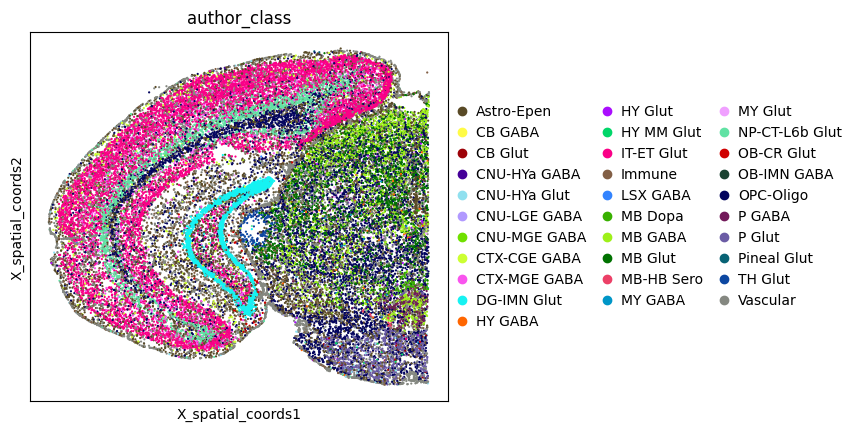

In [9]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='author_class',
        show=False, s=10, palette = class_palette, 
    )
plot.set_aspect('equal')
plt.show()

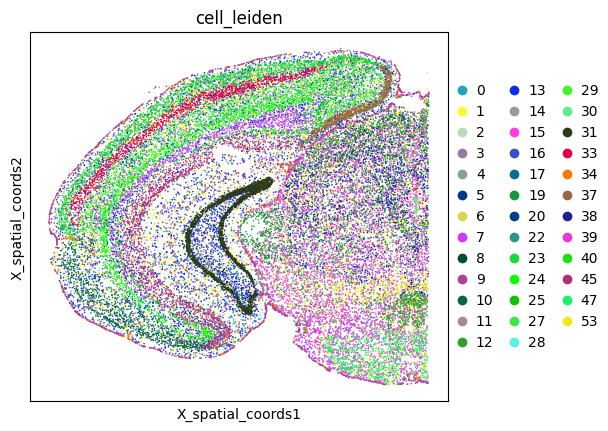

In [16]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='cell_leiden',
        show=False, s=5, palette = cell_leiden_colormap, 
)
plot.set_aspect('equal')
plt.show()

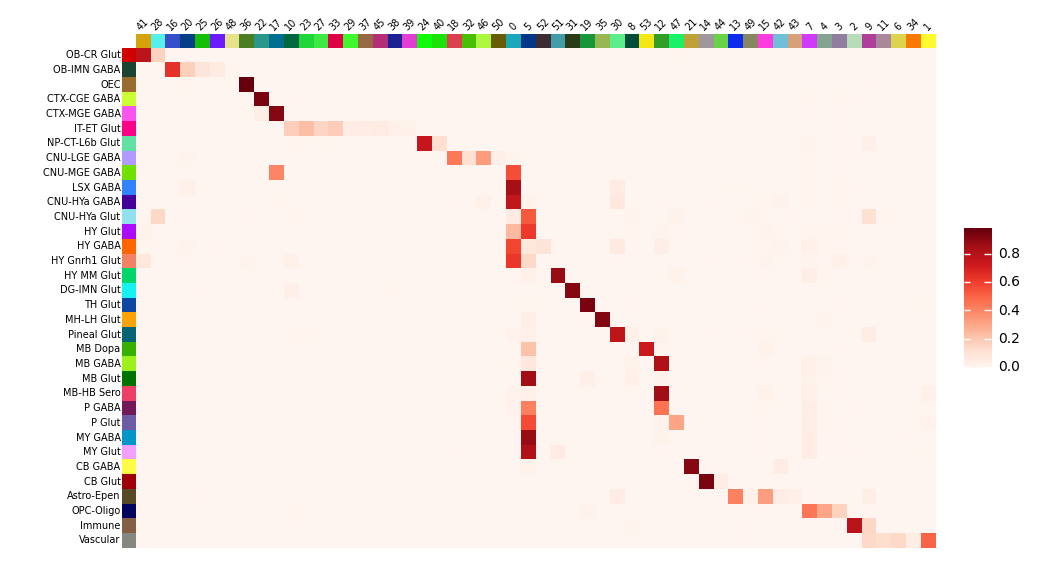

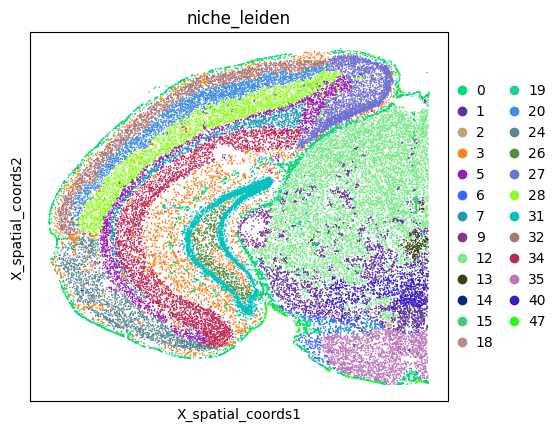

In [20]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='niche_leiden',
        show=False, s=5, palette = niche_leiden_colormap, 
    )
plot.set_aspect('equal')
plt.show()

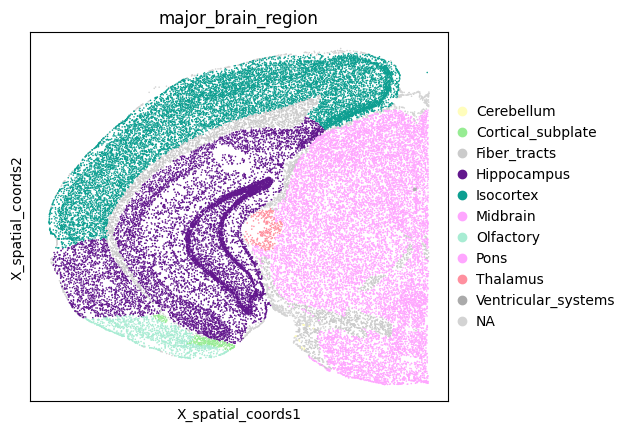

In [21]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='major_brain_region',
        show=False, s=5, palette = major_brain_region_colormap, 
    )
plot.set_aspect('equal')
plt.show()

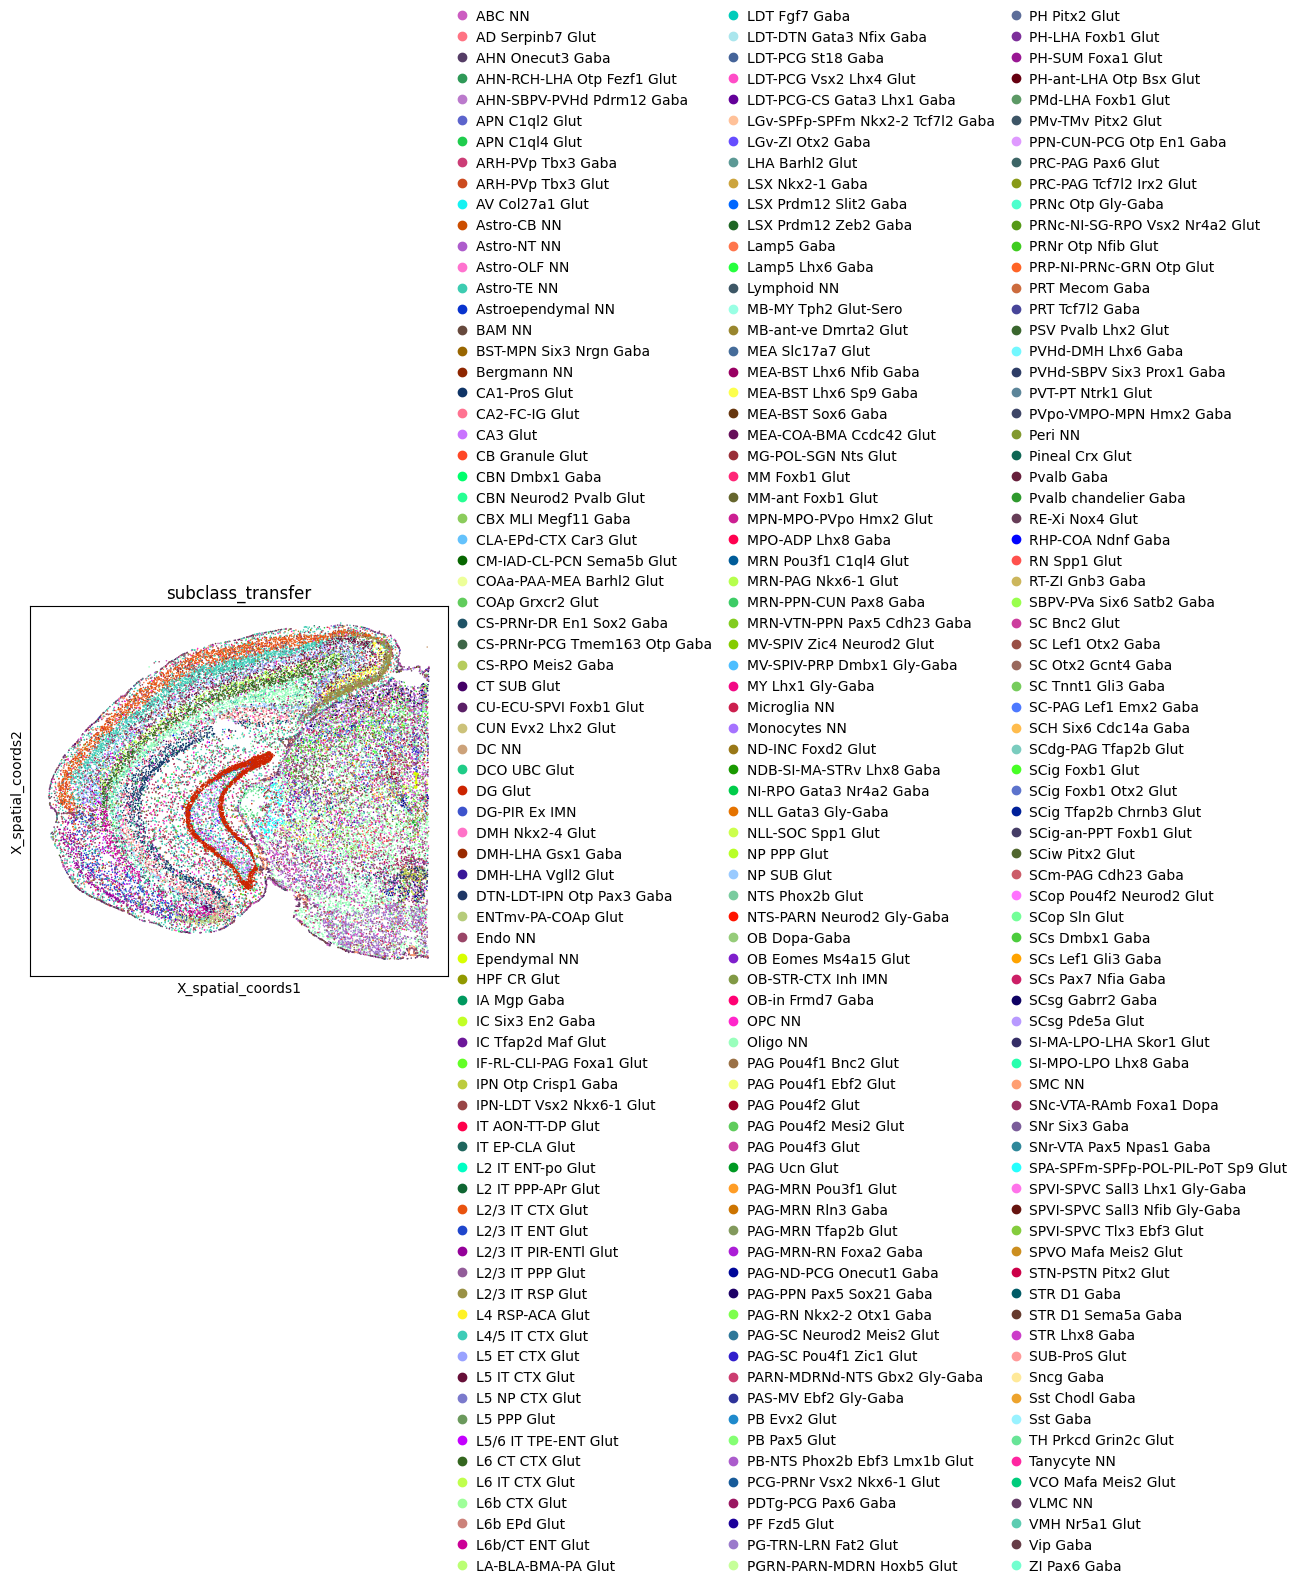

In [22]:
plot = sc.pl.embedding(
        adata_temp, basis="X_spatial_coords", color='subclass_transfer',
        show=False, s=5, palette = subclass_palette, 
    )
plot.set_aspect('equal')
plt.show()

In [70]:
confusion_matrix = pd.crosstab(
    adata.obs['main_region'], 
    adata.obs['niche_leiden'], 
    normalize='index'
)

In [80]:
main_region_order = ['Olfactory areas', 'CTXsp', 'Isocortex',   'Hippocampal formation',  'Hypothalamus',  'Thalamus','Medulla', 'Midbrain',  'Pons',  'Cerebellum', 'Cerebral nuclei',  'Ventricular systems', 'fiber tracts']
niche_leiden_order = [ '4',  '1',  '10', '18', '21', '6','15',  '2',  '3', '11', '12', '13', '14',  '16', '17',  '19', '20',  '22', '23', '24', '5', '7', '8', '9', '0',]
confusion_matrix = confusion_matrix.loc[main_region_order]
confusion_matrix = confusion_matrix[niche_leiden_order]

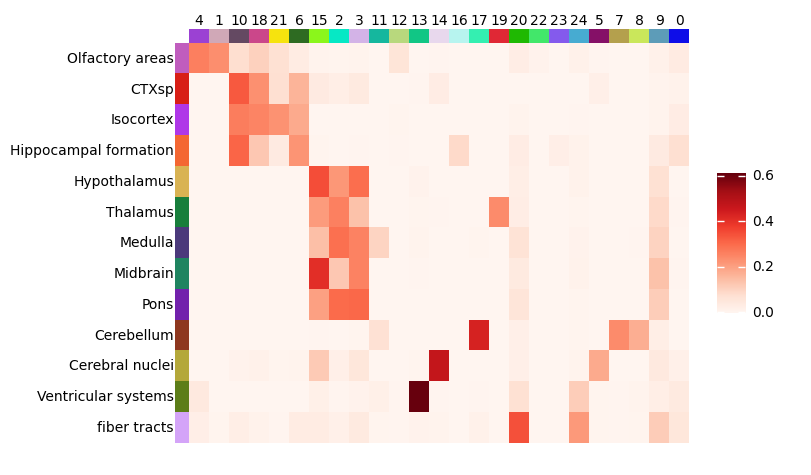

In [81]:
gene_profile = ma.Heatmap(
        confusion_matrix,
        height=4,
        width=5,
        cmap="Reds",
    )

gene_profile.group_rows(main_region_order, order=main_region_order, spacing=0)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=[' ' for i in range(len(main_region_order))], 
        padding=0, 
        fill_colors=[main_region_colormap[i] for i in main_region_order], 
        borderwidth=0
    ),
    pad=0.001
)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=main_region_order,
        padding=0.2,
        fill_colors=None,
        borderwidth=0,
        rotation=0,
    ),
    pad=0.01
)


gene_profile.group_cols(niche_leiden_order, order=niche_leiden_order,spacing = 0)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts = [' ' for i in range(len(niche_leiden_order))], 
        padding=0, 
        fill_colors = [niche_leiden_colormap[i] for i in niche_leiden_order], 
        borderwidth = 0),
    pad=0.001)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts=niche_leiden_order,
        padding=0.2,
        fill_colors=None, 
        borderwidth=0,
        rotation=0,
    ),
    pad=0.01
)

gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()


# plt.savefig("confusion_matrix.pdf", bbox_inches="tight",transparent=True,facecolor='none')
plt.show()